## Setup and Configuration 

In [1]:
# ====================== CELL 1: SETUP AND CONFIGURATION ======================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torch.cuda.amp import autocast, GradScaler
import timm
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

print("="*60)
print("SKIN DIAGNOSIS CLASSIFICATION - SETUP")
print("="*60)

# Configuration
class Config:
    
    base_path = '/kaggle/input/datasets/sumayyanamata/skin-diagnosis/dermnet'
    train_path = os.path.join(base_path, 'train')
    test_path = os.path.join(base_path, 'test')

    img_size = 224
    batch_size = 16
    epochs = 40
    learning_rate = 1e-4

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

config = Config()

print("Device:", config.device)

# Get class names
def get_class_names_from_folders(path):

    classes = []

    for item in sorted(os.listdir(path)):
        item_path = os.path.join(path, item)

        if os.path.isdir(item_path):
            classes.append(item)

    return classes


class_names = get_class_names_from_folders(config.train_path)

NUM_CLASSES = len(class_names)

print("Classes found:", NUM_CLASSES)

# Create dataframe
def create_dataframe_from_folder(folder_path, class_names):

    data = []

    for class_id, class_name in enumerate(class_names):

        class_path = os.path.join(folder_path, class_name)

        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.jpg','.jpeg','.png','.tif','.tiff'))]

        for img in images:

            data.append({
                "image_path": os.path.join(class_name,img),
                "label": class_id,
                "class_name": class_name
            })

    return pd.DataFrame(data)


train_df = create_dataframe_from_folder(config.train_path,class_names)
test_df = create_dataframe_from_folder(config.test_path,class_names)

train_df,val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df["label"],
    random_state=42
)

print("Train:",len(train_df))
print("Validation:",len(val_df))
print("Test:",len(test_df))

# Transforms
train_transform = transforms.Compose([

    transforms.Resize((config.img_size,config.img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([

    transforms.Resize((config.img_size,config.img_size)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# Dataset
class SkinDataset(Dataset):

    def __init__(self,dataframe,root_dir,transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self,idx):

        img_path = os.path.join(
            self.root_dir,
            self.df.iloc[idx]["image_path"]
        )

        try:

            image = Image.open(img_path).convert("RGB")

        except:

            image = Image.new("RGB",(config.img_size,config.img_size))

        label = self.df.iloc[idx]["label"]

        if self.transform:
            image = self.transform(image)

        return image,label


train_dataset = SkinDataset(train_df,config.train_path,train_transform)
val_dataset = SkinDataset(val_df,config.train_path,val_transform)
test_dataset = SkinDataset(test_df,config.test_path,val_transform)

# Class imbalance handling
train_labels = train_df["label"].values

class_counts = np.bincount(train_labels)

class_weights = 1.0 / (class_counts + 1e-6)

sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    sample_weights,
    len(sample_weights),
    replacement=True
)

# DataLoaders
train_loader = DataLoader(train_dataset,batch_size=config.batch_size,sampler=sampler,num_workers=4,pin_memory=True)

val_loader = DataLoader(val_dataset,batch_size=config.batch_size,shuffle=False,num_workers=4,pin_memory=True)

test_loader = DataLoader(test_dataset,batch_size=config.batch_size,shuffle=False,num_workers=4,pin_memory=True)

print("Setup Complete")

SKIN DIAGNOSIS CLASSIFICATION - SETUP
Device: cuda
Classes found: 23
Train: 12659
Validation: 2235
Test: 3457
Setup Complete


## MOBILENET-V3-LARGE 

TRAINING MOBILENET-V3-LARGE (OPTIMIZED)
Number of classes: 23
Device: cuda
Epochs: 40
Class weights available: True

Loading MobileNet-V3-Large...
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 138MB/s] 


✓ MobileNet-V3-Large ready
  Total parameters: 4,231,495
  Trainable parameters: 4,231,495
Epoch [1/40]
  Loss: 2.4773
  Train Accuracy: 20.98%
  Val Accuracy: 23.53%
  Val Kappa: 0.2097
  Macro-F1: 0.2083
  Worst Class F1: 0.0000
  LR: 9.98e-05
--------------------------------------------------
  ✓ Best model saved! Macro-F1: 0.2083
Epoch [2/40]
  Loss: 2.0468
  Train Accuracy: 33.55%
  Val Accuracy: 27.38%
  Val Kappa: 0.2488
  Macro-F1: 0.2600
  Worst Class F1: 0.0398
  LR: 9.94e-05
--------------------------------------------------
  ✓ Best model saved! Macro-F1: 0.2600
Epoch [3/40]
  Loss: 1.8111
  Train Accuracy: 38.74%
  Val Accuracy: 27.83%
  Val Kappa: 0.2536
  Macro-F1: 0.2699
  Worst Class F1: 0.0200
  LR: 9.86e-05
--------------------------------------------------
  ✓ Best model saved! Macro-F1: 0.2699
Epoch [4/40]
  Loss: 1.6605
  Train Accuracy: 42.91%
  Val Accuracy: 32.21%
  Val Kappa: 0.2963
  Macro-F1: 0.3049
  Worst Class F1: 0.0490
  LR: 9.76e-05
-------------------

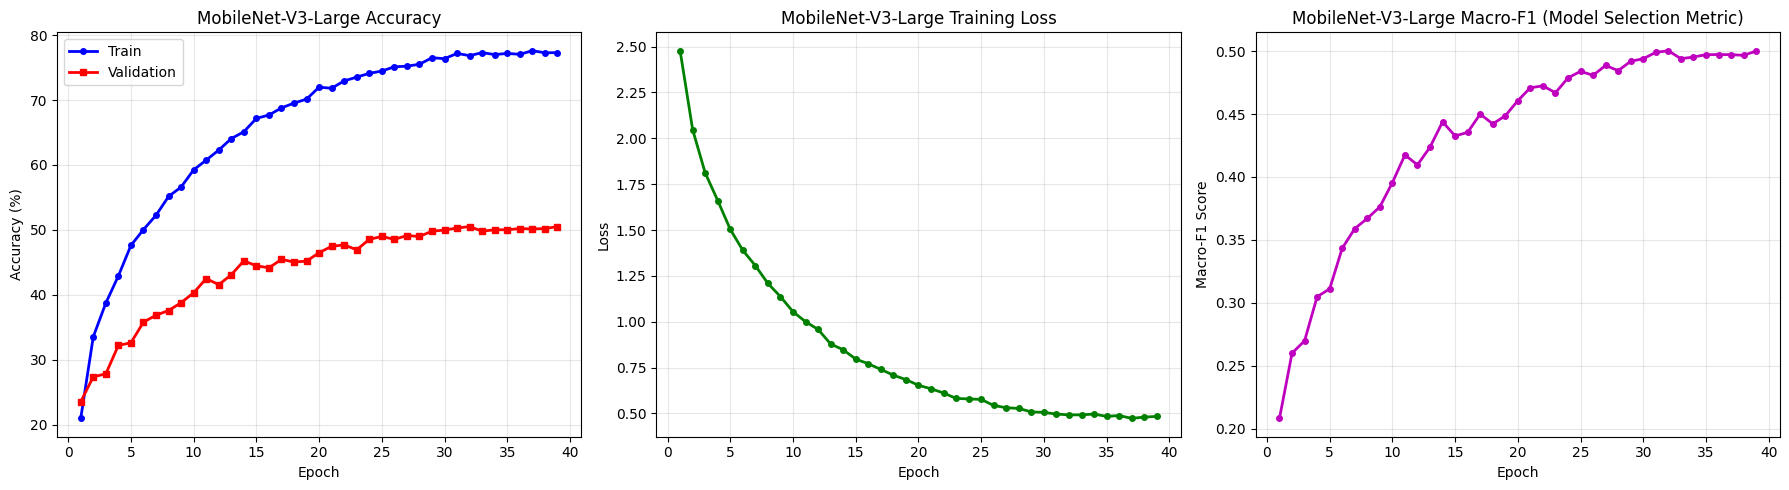


 Training complete! Best Macro-F1: 0.5003


In [2]:
# ====================== MOBILENET-V3-LARGE (MACRO-F1) ======================

print("="*60)
print("TRAINING MOBILENET-V3-LARGE (OPTIMIZED)")
print("="*60)


# Check if required variables exist
try:
    print(f"Number of classes: {NUM_CLASSES}")
    print(f"Device: {config.device}")
    print(f"Epochs: {config.epochs}")
    print(f"Class weights available: {class_weights is not None}")
except NameError as e:
    print(f"Error: {e}")
    print("Make sure you've run Cell 1 (Setup) first!")
    raise

# Load pretrained MobileNet-V3-Large
print("\nLoading MobileNet-V3-Large...")
model_mobilenet = models.mobilenet_v3_large(pretrained=True)

# Replace classifier
in_features = model_mobilenet.classifier[3].in_features
model_mobilenet.classifier[3] = nn.Linear(in_features, NUM_CLASSES)
model_mobilenet = model_mobilenet.to(config.device)

print(f"✓ MobileNet-V3-Large ready")
print(f"  Total parameters: {sum(p.numel() for p in model_mobilenet.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model_mobilenet.parameters() if p.requires_grad):,}")

# Custom training function for MobileNet
def train_mobilenet(model, epochs=config.epochs):
    """
    MobileNet-specific training with:
    - Different learning rates for backbone vs classifier
    - Class weights for imbalance
    - Early stopping based on Macro-F1 (better for imbalanced data)
    """
    
    # Use class weights for imbalance
    class_weights_tensor = torch.FloatTensor(class_weights).to(config.device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    
    # Different learning rates: lower for pretrained features, higher for new classifier
    backbone_params = list(model.features.parameters())
    classifier_params = list(model.classifier.parameters())
    
    optimizer = optim.AdamW([
        {'params': backbone_params, 'lr': config.learning_rate * 0.1},  # Lower LR for backbone
        {'params': classifier_params, 'lr': config.learning_rate}       # Higher LR for classifier
    ], weight_decay=1e-4)
    
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = GradScaler()
    
    # Track best Macro-F1 instead of accuracy
    best_macro_f1 = 0
    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'macro_f1': []}
    
    # Early stopping parameters
    patience = 7
    no_improve = 0
    
    for epoch in range(epochs):
        # ===== TRAINING =====
        model.train()
        running_loss = 0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(config.device), labels.to(config.device)
            
            optimizer.zero_grad()
            
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_acc = 100 * correct / total
        avg_loss = running_loss / len(train_loader)
        
        # ===== VALIDATION =====
        model.eval()
        correct = 0
        total = 0
        val_preds = []
        val_true = []
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(config.device), labels.to(config.device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                
                # Store for metrics
                val_preds.extend(predicted.cpu().numpy())
                val_true.extend(labels.cpu().numpy())
        
        val_acc = 100 * correct / total
        scheduler.step()
        
        # Calculate metrics
        from sklearn.metrics import cohen_kappa_score, f1_score
        val_kappa = cohen_kappa_score(val_true, val_preds)
        macro_f1 = f1_score(val_true, val_preds, average='macro')
        
        # Track worst class performance (optional but informative)
        per_class_f1 = f1_score(val_true, val_preds, average=None)
        worst_f1 = min(per_class_f1)
        
        # Save history
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(avg_loss)
        history['macro_f1'].append(macro_f1)
        
        # Get current learning rate
        current_lr = optimizer.param_groups[1]['lr']
        
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"  Loss: {avg_loss:.4f}")
        print(f"  Train Accuracy: {train_acc:.2f}%")
        print(f"  Val Accuracy: {val_acc:.2f}%")
        print(f"  Val Kappa: {val_kappa:.4f}")
        print(f"  Macro-F1: {macro_f1:.4f}")
        print(f"  Worst Class F1: {worst_f1:.4f}")
        print(f"  LR: {current_lr:.2e}")
        print("-" * 50)
        
        # Save best model based on Macro-F1 (not accuracy)
        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            torch.save(model.state_dict(), "best_mobilenet.pth")
            print(f"  ✓ Best model saved! Macro-F1: {best_macro_f1:.4f}")
            no_improve = 0  # Reset counter when we improve
        else:
            no_improve += 1
            print(f"  No improvement for {no_improve} epochs")
            
            if no_improve >= patience:
                print(f"\n Early stopping triggered at epoch {epoch+1}")
                print(f"Best Macro-F1: {best_macro_f1:.4f}")
                break
    
    print(f"\n MobileNet-V3-Large best Macro-F1: {best_macro_f1:.4f}")
    
    # Plot training history
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Accuracy plot
    axes[0].plot(range(1, len(history['train_acc'])+1), history['train_acc'], 'b-o', label='Train', linewidth=2, markersize=4)
    axes[0].plot(range(1, len(history['val_acc'])+1), history['val_acc'], 'r-s', label='Validation', linewidth=2, markersize=4)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_title('MobileNet-V3-Large Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Loss plot
    axes[1].plot(range(1, len(history['train_loss'])+1), history['train_loss'], 'g-o', linewidth=2, markersize=4)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('MobileNet-V3-Large Training Loss')
    axes[1].grid(True, alpha=0.3)
    
    # Macro-F1 plot
    axes[2].plot(range(1, len(history['macro_f1'])+1), history['macro_f1'], 'm-o', linewidth=2, markersize=4)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Macro-F1 Score')
    axes[2].set_title('MobileNet-V3-Large Macro-F1 (Model Selection Metric)')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('mobilenet_training.png', dpi=150)
    plt.show()
    
    return best_macro_f1

# Train MobileNet with optimized settings
best_f1 = train_mobilenet(model_mobilenet)

print(f"\n Training complete! Best Macro-F1: {best_f1:.4f}")

## EFFICIENTNET-B4

TRAINING EFFICIENTNET-B4 (OPTIMIZED)

Loading EfficientNet-B4 pretrained on ImageNet...


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]


✓ EfficientNet-B4 ready!
  Total parameters: 17,589,855
  Trainable parameters: 17,589,855

Starting optimized training...
Epoch [1/40]
  Loss: 3.0121
  Train Accuracy: 8.82%
  Val Accuracy: 6.13%
  Val Kappa: 0.0395
  Macro-F1: 0.0581
  Mean PR-AUC: 0.0906
  Worst Class F1: 0.0000
  LR: 9.98e-05
--------------------------------------------------
  ✓ Best model saved! Macro-F1: 0.0581
Epoch [2/40]
  Loss: 2.6981
  Train Accuracy: 15.43%
  Val Accuracy: 11.54%
  Val Kappa: 0.0920
  Macro-F1: 0.0961
  Mean PR-AUC: 0.1325
  Worst Class F1: 0.0000
  LR: 9.94e-05
--------------------------------------------------
  ✓ Best model saved! Macro-F1: 0.0961
Epoch [3/40]
  Loss: 2.5179
  Train Accuracy: 20.62%
  Val Accuracy: 15.12%
  Val Kappa: 0.1267
  Macro-F1: 0.1265
  Mean PR-AUC: 0.1583
  Worst Class F1: 0.0000
  LR: 9.86e-05
--------------------------------------------------
  ✓ Best model saved! Macro-F1: 0.1265
Epoch [4/40]
  Loss: 2.3906
  Train Accuracy: 24.22%
  Val Accuracy: 17.00%
 

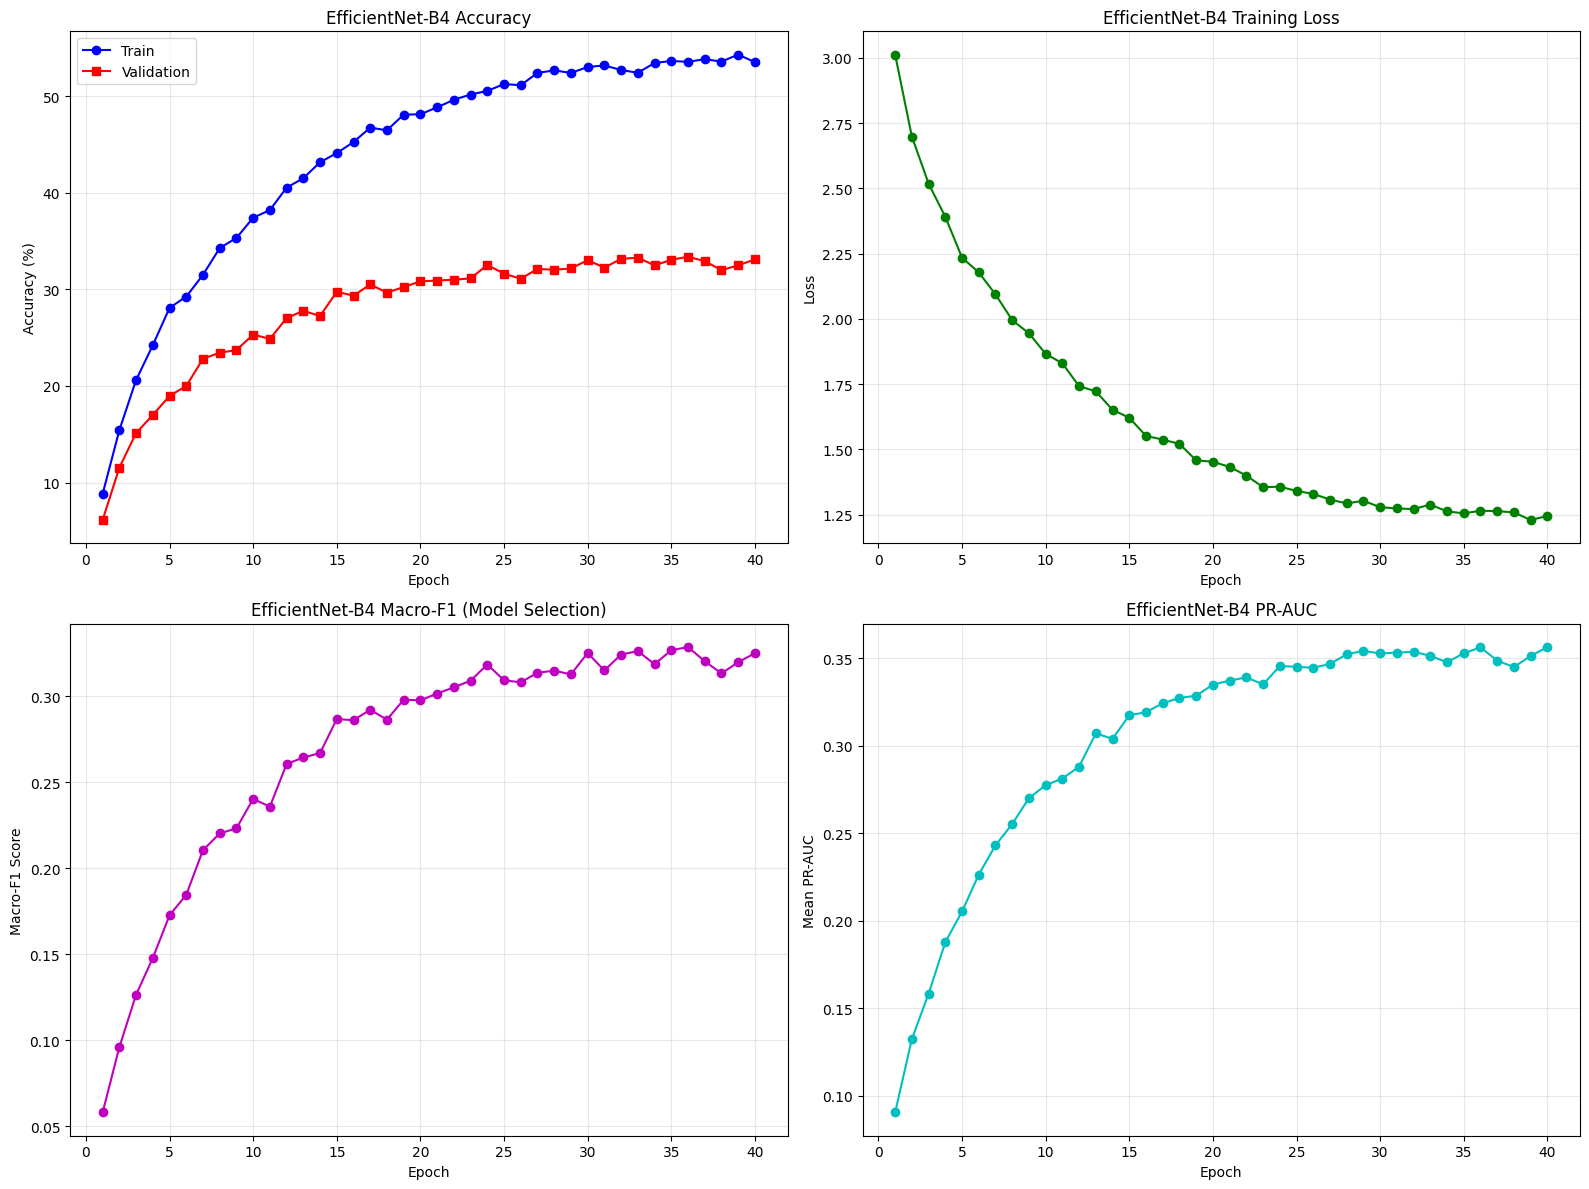


 EfficientNet-B4 training complete! Best Macro-F1: 0.3285
Final PR-AUC: 0.3563


In [2]:
# ====================== EFFICIENTNET-B4 (Macro-F1 + PR-AUC) ======================
# EfficientNet-B4 with optimized training strategy

print("="*60)
print("TRAINING EFFICIENTNET-B4 (OPTIMIZED)")
print("="*60)

import timm
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler

# Load pretrained EfficientNet-B4
print("\nLoading EfficientNet-B4 pretrained on ImageNet...")
model_efnet = timm.create_model(
    'efficientnet_b4',
    pretrained=True,
    num_classes=NUM_CLASSES
)
model_efnet = model_efnet.to(config.device)

print(f"\n✓ EfficientNet-B4 ready!")
print(f"  Total parameters: {sum(p.numel() for p in model_efnet.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model_efnet.parameters() if p.requires_grad):,}")

# Custom training function for EfficientNet (similar to MobileNet optimized)
def train_efficientnet(model, epochs=config.epochs):
    """
    Optimized training for EfficientNet-B4 with Macro-F1 model selection
    """
    
    # Class weights for imbalance
    class_weights_tensor = torch.FloatTensor(class_weights).to(config.device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    
    # Separate parameters for different learning rates
    # EfficientNet has 'features' (backbone) and 'classifier'
    backbone_params = []
    classifier_params = []
    
    for name, param in model.named_parameters():
        if 'classifier' in name:
            classifier_params.append(param)
        else:
            backbone_params.append(param)
    
    # Different learning rates: lower for backbone, higher for classifier
    optimizer = optim.AdamW([
        {'params': backbone_params, 'lr': config.learning_rate * 0.1},
        {'params': classifier_params, 'lr': config.learning_rate}
    ], weight_decay=1e-4)
    
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = GradScaler()
    
    # Track best Macro-F1 instead of accuracy
    best_macro_f1 = 0
    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 
               'macro_f1': [], 'pr_auc': []}
    
    # Early stopping
    patience = 7
    no_improve = 0
    
    for epoch in range(epochs):
        # Training
        model.train()
        running_loss = 0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(config.device), labels.to(config.device)
            
            optimizer.zero_grad()
            
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_acc = 100 * correct / total
        avg_loss = running_loss / len(train_loader)
        
        # Validation
        model.eval()
        correct = 0
        total = 0
        val_preds = []
        val_true = []
        val_probs = []  # NEW: Store probabilities for PR-AUC
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(config.device), labels.to(config.device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                
                val_preds.extend(predicted.cpu().numpy())
                val_true.extend(labels.cpu().numpy())
                
                # NEW: Store probabilities for PR-AUC
                probabilities = torch.softmax(outputs, dim=1).cpu().numpy()
                val_probs.extend(probabilities)
        
        val_acc = 100 * correct / total
        scheduler.step()
        
        # Calculate metrics
        from sklearn.metrics import cohen_kappa_score, f1_score, precision_recall_curve, auc
        import numpy as np
        
        val_kappa = cohen_kappa_score(val_true, val_preds)
        macro_f1 = f1_score(val_true, val_preds, average='macro')
        
        # Track worst class performance
        per_class_f1 = f1_score(val_true, val_preds, average=None)
        worst_f1 = min(per_class_f1)
        
        # NEW: Calculate PR-AUC
        val_true_array = np.array(val_true)
        val_probs_array = np.array(val_probs)
        
        pr_auc_scores = []
        for class_idx in range(NUM_CLASSES):
            y_true_binary = (val_true_array == class_idx).astype(int)
            y_scores = val_probs_array[:, class_idx]
            
            if len(np.unique(y_true_binary)) > 1:
                precision, recall, _ = precision_recall_curve(y_true_binary, y_scores)
                pr_auc = auc(recall, precision)
            else:
                pr_auc = 0.0
            pr_auc_scores.append(pr_auc)
        
        mean_pr_auc = np.mean(pr_auc_scores)
        
        # Save history
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(avg_loss)
        history['macro_f1'].append(macro_f1)
        history['pr_auc'].append(mean_pr_auc)
        
        current_lr = optimizer.param_groups[1]['lr']
        
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"  Loss: {avg_loss:.4f}")
        print(f"  Train Accuracy: {train_acc:.2f}%")
        print(f"  Val Accuracy: {val_acc:.2f}%")
        print(f"  Val Kappa: {val_kappa:.4f}")
        print(f"  Macro-F1: {macro_f1:.4f}")        # Model selection metric
        print(f"  Mean PR-AUC: {mean_pr_auc:.4f}")   # Additional metric
        print(f"  Worst Class F1: {worst_f1:.4f}")
        print(f"  LR: {current_lr:.2e}")
        print("-" * 50)
        
        # Save best model based on Macro-F1 (not accuracy)
        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            torch.save(model.state_dict(), "best_efficientnet.pth")
            print(f"  ✓ Best model saved! Macro-F1: {best_macro_f1:.4f}")
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"\n Early stopping at epoch {epoch+1}")
                print(f"Best Macro-F1: {best_macro_f1:.4f}")
                break
    
    print(f"\n EfficientNet-B4 best Macro-F1: {best_macro_f1:.4f}")
    
    # Plot training history (now 4 plots)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Accuracy
    axes[0,0].plot(range(1, len(history['train_acc'])+1), history['train_acc'], 'b-o', label='Train')
    axes[0,0].plot(range(1, len(history['val_acc'])+1), history['val_acc'], 'r-s', label='Validation')
    axes[0,0].set_title('EfficientNet-B4 Accuracy')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Accuracy (%)')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Loss
    axes[0,1].plot(range(1, len(history['train_loss'])+1), history['train_loss'], 'g-o')
    axes[0,1].set_title('EfficientNet-B4 Training Loss')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Loss')
    axes[0,1].grid(True, alpha=0.3)
    
    # Macro-F1
    axes[1,0].plot(range(1, len(history['macro_f1'])+1), history['macro_f1'], 'm-o')
    axes[1,0].set_title('EfficientNet-B4 Macro-F1 (Model Selection)')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Macro-F1 Score')
    axes[1,0].grid(True, alpha=0.3)
    
    # PR-AUC
    axes[1,1].plot(range(1, len(history['pr_auc'])+1), history['pr_auc'], 'c-o')
    axes[1,1].set_title('EfficientNet-B4 PR-AUC')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('Mean PR-AUC')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('efficientnet_training.png', dpi=150)
    plt.show()
    
    return best_macro_f1, history

# Train EfficientNet with optimized settings
print("\nStarting optimized training...")
best_f1, history = train_efficientnet(model_efnet)

print(f"\n EfficientNet-B4 training complete! Best Macro-F1: {best_f1:.4f}")
print(f"Final PR-AUC: {history['pr_auc'][-1]:.4f}")

## RESNET50

TRAINING RESNET50 (OPTIMIZED)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 192MB/s]


✓ ResNet50 ready
  Total parameters: 23,555,159
  Trainable parameters: 23,555,159

Starting optimized training...
Epoch [1/40]
  Loss: 2.1237
  Train Accuracy: 29.98%
  Val Accuracy: 27.70%
  Val Kappa: 0.2515
  Macro-F1: 0.2718
  Mean PR-AUC: 0.3343
  Worst Class F1: 0.0000
  LR: 9.98e-05
--------------------------------------------------
  ✓ Best model saved! Macro-F1: 0.2718
Epoch [2/40]
  Loss: 1.4982
  Train Accuracy: 46.30%
  Val Accuracy: 33.29%
  Val Kappa: 0.3075
  Macro-F1: 0.3248
  Mean PR-AUC: 0.3876
  Worst Class F1: 0.0200
  LR: 9.94e-05
--------------------------------------------------
  ✓ Best model saved! Macro-F1: 0.3248
Epoch [3/40]
  Loss: 1.1667
  Train Accuracy: 55.16%
  Val Accuracy: 36.60%
  Val Kappa: 0.3400
  Macro-F1: 0.3726
  Mean PR-AUC: 0.4373
  Worst Class F1: 0.0518
  LR: 9.86e-05
--------------------------------------------------
  ✓ Best model saved! Macro-F1: 0.3726
Epoch [4/40]
  Loss: 0.9443
  Train Accuracy: 62.17%
  Val Accuracy: 39.96%
  Val Ka

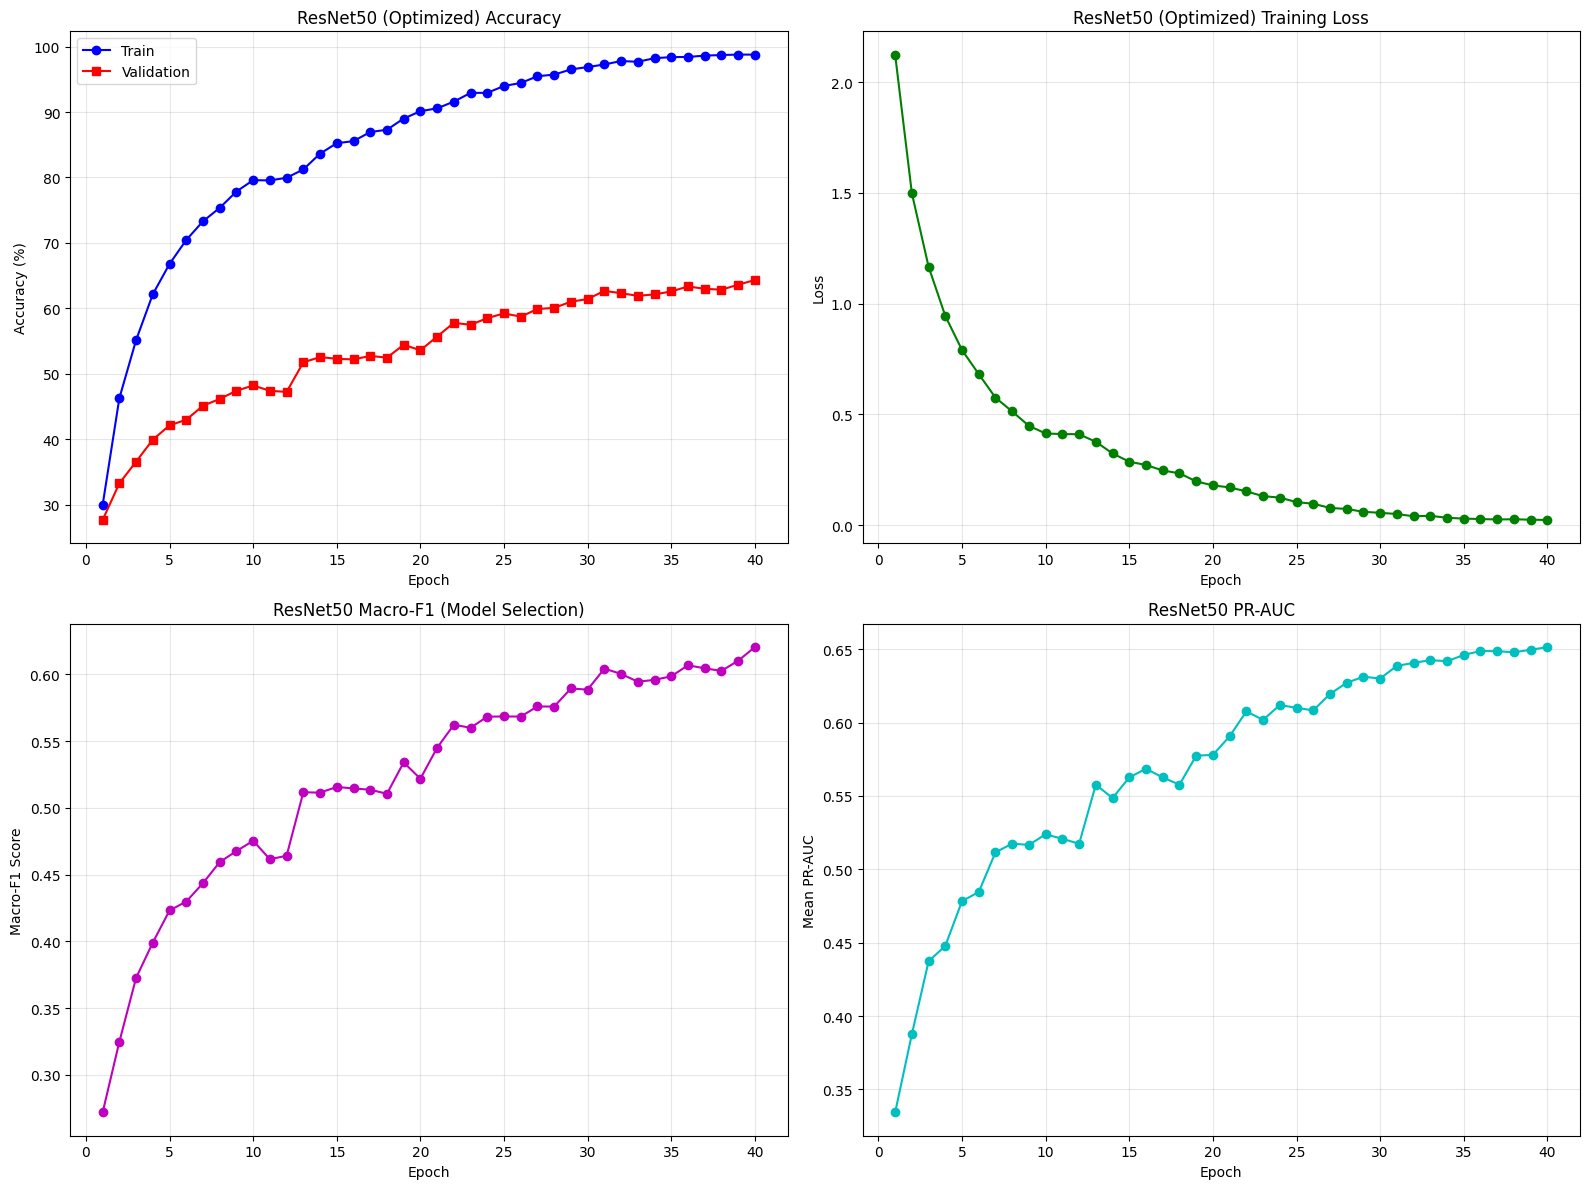


 ResNet50 optimized training complete! Best Macro-F1: 0.6205
Final PR-AUC: 0.6514


In [3]:
# ======================  RESNET50 ( with Macro-F1 + PR-AUC) ======================
print("="*60)
print("TRAINING RESNET50 (OPTIMIZED)")
print("="*60)

# Load pretrained ResNet50
model_resnet_opt = models.resnet50(pretrained=True)

# Replace classifier
model_resnet_opt.fc = nn.Linear(model_resnet_opt.fc.in_features, NUM_CLASSES)
model_resnet_opt = model_resnet_opt.to(config.device)

print(f"✓ ResNet50 ready")
print(f"  Total parameters: {sum(p.numel() for p in model_resnet_opt.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model_resnet_opt.parameters() if p.requires_grad):,}")

def train_resnet50_optimized(model, epochs=config.epochs):
    """
    Optimized training for ResNet50 with:
    - Different learning rates for layers
    - Class weights for imbalance
    - Early stopping based on Macro-F1
    - Layer-wise progressive unfreezing
    - Tracks Macro-F1 and PR-AUC
    """
    
    # Class weights for imbalance
    class_weights_tensor = torch.FloatTensor(class_weights).to(config.device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    
    # Progressive unfreezing - freeze early layers first
    # Only train the last two bottleneck layers initially
    for name, param in model.named_parameters():
        if 'layer4' in name or 'fc' in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
    
    # Different learning rates for different parts
    optimizer = optim.AdamW([
        {'params': model.layer4.parameters(), 'lr': config.learning_rate * 0.5},
        {'params': model.fc.parameters(), 'lr': config.learning_rate}
    ], weight_decay=1e-4)
    
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = GradScaler()
    
    # Track best Macro-F1 instead of accuracy
    best_macro_f1 = 0
    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 
               'macro_f1': [], 'pr_auc': []}
    
    # Early stopping
    patience = 7
    no_improve = 0
    
    for epoch in range(epochs):
        # Gradually unfreeze more layers after epoch 10
        if epoch == 10:
            print("\n🔄 Unfreezing layer3...")
            for param in model.layer3.parameters():
                param.requires_grad = True
            # Recreate optimizer with new parameters
            optimizer = optim.AdamW([
                {'params': model.layer3.parameters(), 'lr': config.learning_rate * 0.3},
                {'params': model.layer4.parameters(), 'lr': config.learning_rate * 0.5},
                {'params': model.fc.parameters(), 'lr': config.learning_rate}
            ], weight_decay=1e-4)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs-10)
        
        # Training
        model.train()
        running_loss = 0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(config.device), labels.to(config.device)
            
            optimizer.zero_grad()
            
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_acc = 100 * correct / total
        avg_loss = running_loss / len(train_loader)
        
        # Validation
        model.eval()
        correct = 0
        total = 0
        val_preds = []
        val_true = []
        val_probs = []  # NEW: Store probabilities for PR-AUC
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(config.device), labels.to(config.device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                
                val_preds.extend(predicted.cpu().numpy())
                val_true.extend(labels.cpu().numpy())
                
                # NEW: Store probabilities for PR-AUC
                probabilities = torch.softmax(outputs, dim=1).cpu().numpy()
                val_probs.extend(probabilities)
        
        val_acc = 100 * correct / total
        scheduler.step()
        
        # Calculate metrics
        from sklearn.metrics import cohen_kappa_score, f1_score, precision_recall_curve, auc
        import numpy as np
        
        val_kappa = cohen_kappa_score(val_true, val_preds)
        macro_f1 = f1_score(val_true, val_preds, average='macro')
        
        # Track worst class performance
        per_class_f1 = f1_score(val_true, val_preds, average=None)
        worst_f1 = min(per_class_f1)
        
        # NEW: Calculate PR-AUC
        val_true_array = np.array(val_true)
        val_probs_array = np.array(val_probs)
        
        pr_auc_scores = []
        for class_idx in range(NUM_CLASSES):
            y_true_binary = (val_true_array == class_idx).astype(int)
            y_scores = val_probs_array[:, class_idx]
            
            if len(np.unique(y_true_binary)) > 1:
                precision, recall, _ = precision_recall_curve(y_true_binary, y_scores)
                pr_auc = auc(recall, precision)
            else:
                pr_auc = 0.0
            pr_auc_scores.append(pr_auc)
        
        mean_pr_auc = np.mean(pr_auc_scores)
        
        # Save history
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(avg_loss)
        history['macro_f1'].append(macro_f1)
        history['pr_auc'].append(mean_pr_auc)
        
        # Get current learning rate
        current_lr = optimizer.param_groups[-1]['lr']
        
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"  Loss: {avg_loss:.4f}")
        print(f"  Train Accuracy: {train_acc:.2f}%")
        print(f"  Val Accuracy: {val_acc:.2f}%")
        print(f"  Val Kappa: {val_kappa:.4f}")
        print(f"  Macro-F1: {macro_f1:.4f}")        # Model selection metric
        print(f"  Mean PR-AUC: {mean_pr_auc:.4f}")   # Additional metric
        print(f"  Worst Class F1: {worst_f1:.4f}")
        print(f"  LR: {current_lr:.2e}")
        print("-" * 50)
        
        # Save best model based on Macro-F1 (not accuracy)
        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            torch.save(model.state_dict(), "best_resnet50_optimized.pth")
            print(f"  ✓ Best model saved! Macro-F1: {best_macro_f1:.4f}")
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"\n Early stopping at epoch {epoch+1}")
                print(f"Best Macro-F1: {best_macro_f1:.4f}")
                break
    
    print(f"\n ResNet50 best Macro-F1: {best_macro_f1:.4f}")
    
    # Plot training history (now 4 plots)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Accuracy
    axes[0,0].plot(range(1, len(history['train_acc'])+1), history['train_acc'], 'b-o', label='Train')
    axes[0,0].plot(range(1, len(history['val_acc'])+1), history['val_acc'], 'r-s', label='Validation')
    axes[0,0].set_title('ResNet50 (Optimized) Accuracy')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Accuracy (%)')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Loss
    axes[0,1].plot(range(1, len(history['train_loss'])+1), history['train_loss'], 'g-o')
    axes[0,1].set_title('ResNet50 (Optimized) Training Loss')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Loss')
    axes[0,1].grid(True, alpha=0.3)
    
    # Macro-F1
    axes[1,0].plot(range(1, len(history['macro_f1'])+1), history['macro_f1'], 'm-o')
    axes[1,0].set_title('ResNet50 Macro-F1 (Model Selection)')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Macro-F1 Score')
    axes[1,0].grid(True, alpha=0.3)
    
    # PR-AUC
    axes[1,1].plot(range(1, len(history['pr_auc'])+1), history['pr_auc'], 'c-o')
    axes[1,1].set_title('ResNet50 PR-AUC')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('Mean PR-AUC')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('resnet50_optimized_training.png', dpi=150)
    plt.show()
    
    return best_macro_f1, history

# Train optimized ResNet50
print("\nStarting optimized training...")
best_f1, history = train_resnet50_optimized(model_resnet_opt)
print(f"\n ResNet50 optimized training complete! Best Macro-F1: {best_f1:.4f}")
print(f"Final PR-AUC: {history['pr_auc'][-1]:.4f}")

## OPTIMIZED SWIN TRANSFORMER

TRAINING SWIN TRANSFORMER (OPTIMIZED)


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

✓ Swin Transformer ready
  Total parameters: 27,537,041
  Trainable parameters: 27,537,041

Starting optimized training...
Epoch [1/40]
  Loss: 2.5074
  Train Accuracy: 20.67%
  Val Accuracy: 21.30%
  Val Kappa: 0.1880
  Macro-F1: 0.1927
  Mean PR-AUC: 0.2368
  Worst Class F1: 0.0097
  LR: 4.00e-07
--------------------------------------------------
  ✓ Best model saved! Macro-F1: 0.1927
Epoch [2/40]
  Loss: 1.8202
  Train Accuracy: 39.11%
  Val Accuracy: 33.11%
  Val Kappa: 0.3062
  Macro-F1: 0.3225
  Mean PR-AUC: 0.3859
  Worst Class F1: 0.0103
  LR: 6.00e-07
--------------------------------------------------
  ✓ Best model saved! Macro-F1: 0.3225
Epoch [3/40]
  Loss: 1.3375
  Train Accuracy: 52.28%
  Val Accuracy: 41.30%
  Val Kappa: 0.3877
  Macro-F1: 0.4020
  Mean PR-AUC: 0.4688
  Worst Class F1: 0.0686
  LR: 8.00e-07
--------------------------------------------------
  ✓ Best model saved! Macro-F1: 0.4020
Epoch [4/40]
  Loss: 0.9907
  Train Accuracy: 62.15%
  Val Accuracy: 46.49%


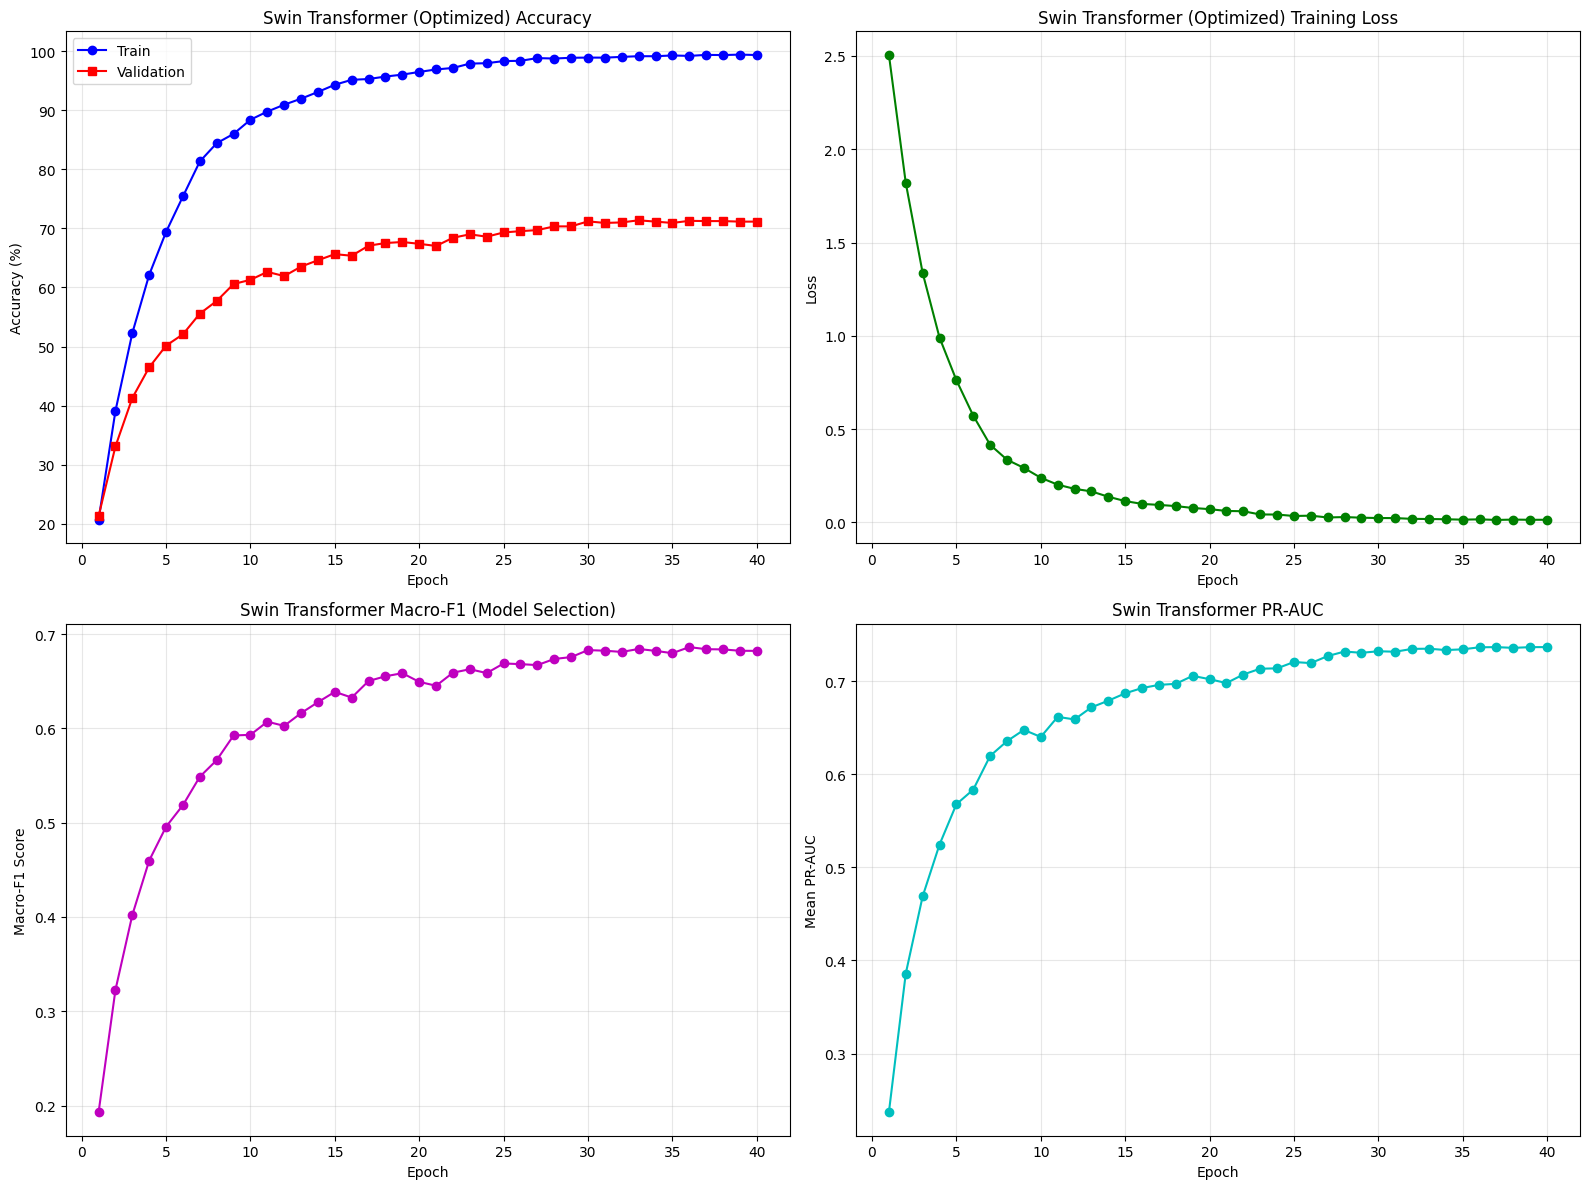


 Swin Transformer optimized training complete! Best Macro-F1: 0.6861
Final PR-AUC: 0.7366


In [2]:
# ====================== SWIN TRANSFORMER (Macro-F1 + PR-AUC) ======================
print("="*60)
print("TRAINING SWIN TRANSFORMER (OPTIMIZED)")
print("="*60)

# Load pretrained Swin Transformer
model_swin_opt = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=NUM_CLASSES
)
model_swin_opt = model_swin_opt.to(config.device)

print(f"✓ Swin Transformer ready")
print(f"  Total parameters: {sum(p.numel() for p in model_swin_opt.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model_swin_opt.parameters() if p.requires_grad):,}")

def train_swin_optimized(model, epochs=config.epochs):
    """
    Optimized training for Swin Transformer with:
    - Learning rate warmup (critical for transformers)
    - Layer-wise learning rate decay
    - Gradient clipping
    - Class weights
    - Early stopping based on Macro-F1
    - Tracks Macro-F1 and PR-AUC
    """
    
    # Class weights for imbalance
    class_weights_tensor = torch.FloatTensor(class_weights).to(config.device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    
    # Swin Transformer specific settings
    # Different learning rates for different stages
    parameters = []
    
    # Stage-specific learning rates (deeper layers get higher LR)
    for name, param in model.named_parameters():
        if 'head' in name or 'norm' in name:
            parameters.append({'params': param, 'lr': config.learning_rate})
        elif 'layers.3' in name:  # Last stage
            parameters.append({'params': param, 'lr': config.learning_rate * 0.5})
        elif 'layers.2' in name:  # Third stage
            parameters.append({'params': param, 'lr': config.learning_rate * 0.3})
        elif 'layers.1' in name:  # Second stage
            parameters.append({'params': param, 'lr': config.learning_rate * 0.1})
        elif 'layers.0' in name:  # First stage
            parameters.append({'params': param, 'lr': config.learning_rate * 0.05})
        else:  # Patch embedding, etc.
            parameters.append({'params': param, 'lr': config.learning_rate * 0.01})
    
    optimizer = optim.AdamW(parameters, weight_decay=1e-4)
    
    # Learning rate warmup (critical for transformers)
    warmup_epochs = 5
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        else:
            return 0.5 * (1 + np.cos(np.pi * (epoch - warmup_epochs) / (epochs - warmup_epochs)))
    
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    
    # Gradient clipping for stability
    scaler = GradScaler()
    
    # Track best Macro-F1 instead of accuracy
    best_macro_f1 = 0
    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 
               'macro_f1': [], 'pr_auc': []}
    
    # Early stopping
    patience = 7
    no_improve = 0
    
    for epoch in range(epochs):
        # Training
        model.train()
        running_loss = 0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(config.device), labels.to(config.device)
            
            optimizer.zero_grad()
            
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            
            # Gradient clipping (important for transformers)
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            scaler.step(optimizer)
            scaler.update()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_acc = 100 * correct / total
        avg_loss = running_loss / len(train_loader)
        
        # Validation
        model.eval()
        correct = 0
        total = 0
        val_preds = []
        val_true = []
        val_probs = []  # NEW: Store probabilities for PR-AUC
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(config.device), labels.to(config.device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                
                val_preds.extend(predicted.cpu().numpy())
                val_true.extend(labels.cpu().numpy())
                
                # NEW: Store probabilities for PR-AUC
                probabilities = torch.softmax(outputs, dim=1).cpu().numpy()
                val_probs.extend(probabilities)
        
        val_acc = 100 * correct / total
        scheduler.step()
        
        # Calculate metrics
        from sklearn.metrics import cohen_kappa_score, f1_score, precision_recall_curve, auc
        import numpy as np
        
        val_kappa = cohen_kappa_score(val_true, val_preds)
        macro_f1 = f1_score(val_true, val_preds, average='macro')
        
        # Track worst class performance
        per_class_f1 = f1_score(val_true, val_preds, average=None)
        worst_f1 = min(per_class_f1)
        
        # NEW: Calculate PR-AUC
        val_true_array = np.array(val_true)
        val_probs_array = np.array(val_probs)
        
        pr_auc_scores = []
        for class_idx in range(NUM_CLASSES):
            y_true_binary = (val_true_array == class_idx).astype(int)
            y_scores = val_probs_array[:, class_idx]
            
            if len(np.unique(y_true_binary)) > 1:
                precision, recall, _ = precision_recall_curve(y_true_binary, y_scores)
                pr_auc = auc(recall, precision)
            else:
                pr_auc = 0.0
            pr_auc_scores.append(pr_auc)
        
        mean_pr_auc = np.mean(pr_auc_scores)
        
        # Save history
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(avg_loss)
        history['macro_f1'].append(macro_f1)
        history['pr_auc'].append(mean_pr_auc)
        
        # Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"  Loss: {avg_loss:.4f}")
        print(f"  Train Accuracy: {train_acc:.2f}%")
        print(f"  Val Accuracy: {val_acc:.2f}%")
        print(f"  Val Kappa: {val_kappa:.4f}")
        print(f"  Macro-F1: {macro_f1:.4f}")        # Model selection metric
        print(f"  Mean PR-AUC: {mean_pr_auc:.4f}")   # Additional metric
        print(f"  Worst Class F1: {worst_f1:.4f}")
        print(f"  LR: {current_lr:.2e}")
        print("-" * 50)
        
        # Save best model based on Macro-F1 (not accuracy)
        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            torch.save(model.state_dict(), "best_swin_optimized.pth")
            print(f"  ✓ Best model saved! Macro-F1: {best_macro_f1:.4f}")
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"\n Early stopping at epoch {epoch+1}")
                print(f"Best Macro-F1: {best_macro_f1:.4f}")
                break
    
    print(f"\n Swin Transformer best Macro-F1: {best_macro_f1:.4f}")
    
    # Plot training history (now 4 plots)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Accuracy
    axes[0,0].plot(range(1, len(history['train_acc'])+1), history['train_acc'], 'b-o', label='Train')
    axes[0,0].plot(range(1, len(history['val_acc'])+1), history['val_acc'], 'r-s', label='Validation')
    axes[0,0].set_title('Swin Transformer (Optimized) Accuracy')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Accuracy (%)')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Loss
    axes[0,1].plot(range(1, len(history['train_loss'])+1), history['train_loss'], 'g-o')
    axes[0,1].set_title('Swin Transformer (Optimized) Training Loss')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Loss')
    axes[0,1].grid(True, alpha=0.3)
    
    # Macro-F1
    axes[1,0].plot(range(1, len(history['macro_f1'])+1), history['macro_f1'], 'm-o')
    axes[1,0].set_title('Swin Transformer Macro-F1 (Model Selection)')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Macro-F1 Score')
    axes[1,0].grid(True, alpha=0.3)
    
    # PR-AUC
    axes[1,1].plot(range(1, len(history['pr_auc'])+1), history['pr_auc'], 'c-o')
    axes[1,1].set_title('Swin Transformer PR-AUC')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('Mean PR-AUC')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('swin_optimized_training.png', dpi=150)
    plt.show()
    
    return best_macro_f1, history

# Train optimized Swin Transformer
print("\nStarting optimized training...")
best_f1, history = train_swin_optimized(model_swin_opt)
print(f"\n Swin Transformer optimized training complete! Best Macro-F1: {best_f1:.4f}")
print(f"Final PR-AUC: {history['pr_auc'][-1]:.4f}")